# Feedback Mechanism Analysis

This notebook reproduces the main feedback-mechanism figures. The analysis links post-task self reports and pre/post attitude shifts to observed A1 engagement groups, while the detailed data preparation and plotting helpers live in the repository modules.


## Setup

The setup resolves repository paths, imports the survey summaries and plotting helpers, and applies the shared figure style. Figures are written to `figures/`; interactive display is controlled by `SHOW_FIGURES`.


In [1]:
from pathlib import Path
import sys
import warnings
import matplotlib.pyplot as plt

# Suppress display-only warnings so notebook output stays focused on the analysis results.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
# Clear figures left open by previous interactive runs before saving new PDFs.
plt.close("all")


def _find_repo_root():
    """Find the repository root from either Jupyter or the test runner."""
    # The working directory may be the repository root or a nested directory.
    # Walking upward makes path resolution stable across both cases.
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "analyze").exists():
            return candidate
    raise RuntimeError("Could not locate repository root.")


def _data_path(*candidates):
    """Return the first existing path across current and legacy data layouts."""
    # Some source files have old EduAnalyze paths; fallbacks keep the notebook portable.
    for candidate in candidates:
        path = Path(candidate)
        if not path.is_absolute():
            path = REPO_ROOT / path
        if path.exists():
            return path
    return REPO_ROOT / candidates[0]


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Figures are written here unless the automated test runner redirects them.
FIGURES_DIR = REPO_ROOT / "figures"
SHOW_FIGURES = True
print("Repository:", ".")
print("Figures:", "figures")


Repository: .
Figures: figures


In [2]:
import analyze.survey.feedback as survey_feedback
import analyze.visualization.feedback_plots as feedback_plots
from analyze.background.inequality import _set_nature_style_like_a1_behavior_analyze

_set_nature_style_like_a1_behavior_analyze()


## Build Mechanism Dataset

The dataset joins valid users, observed A1 engagement groups, post-survey self reports, and matched pre/post attitudes. Control students remain in the attitude-shift figures, while Experimental students are split into limited engagement and proactive and critical engagement.


In [3]:
mechanism_df = survey_feedback.build_feedback_mechanism_dataset()
mechanism_df["feedback_group"].value_counts().rename_axis("feedback_group").reset_index(name="n")



Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79

Loading capability scores...
  Loaded captest for 80 Python users and 237 Math users

Loading homework scores...
  Loaded homework scores for 81 Python users and 237 Math users

Loading presurvey data...
  Loaded presurvey data for 318 users

Merging presurvey data for python...
  Merged presurvey data for 81 python users

Preparing covariates for python...
  Major classification: {'CS': 36, 'EE': 16, 'Other Engineering': 15, 'Math & Stat': 6, 'Natural Science': 3, 'Business': 2, 'Humanities': 2, 'Applied Science': 1}
  Prepared covariates for 81 python users

Merging presurvey data for math...
  Merged presurvey data for 237 math users

Preparing covariates for math...
  Major classification: {'Humanities': 55, 'CS': 48, 'Other Engineering': 40, 'EE': 35, 'Business': 19, 'Unknown': 15, 'Math & Stat': 14, 'Applied Science': 6, 'Natural Scie

,feedback_group,n
0,passive,113
1,control,106
2,proactive_critical,99


## Self-Reported Integration Pattern

This figure compares reported integration patterns between limited engagement and proactive and critical engagement students. The non-informative `Unable to use assistant` option is omitted for this mechanism comparison. Panel order: Game Theory left, Python right.


Saved plot to: feedback_mechanism_self_report_by_behavior.pdf


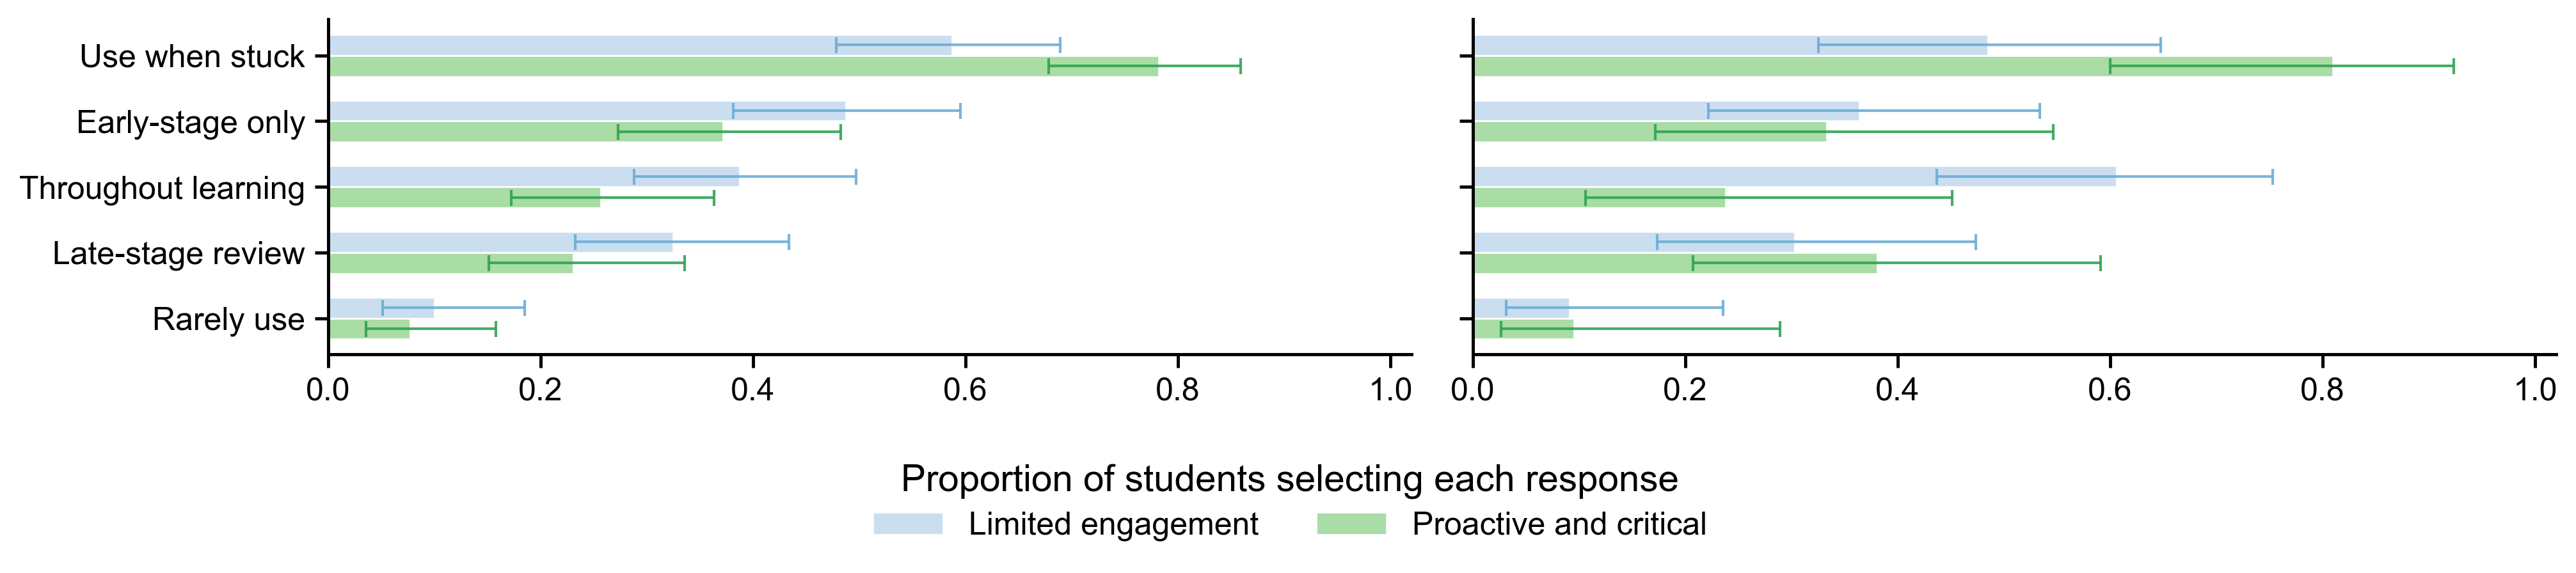

,course,feedback_group,question,question_label,response,n,count,rate,ci95_low,ci95_high
0,math,passive,目的_3,Integration pattern,Use when stuck,80,47,0.587500,0.478038,0.688943
1,math,passive,目的_3,Integration pattern,Throughout learning,80,31,0.387500,0.288244,0.497065
2,math,passive,目的_3,Integration pattern,Early-stage only,80,39,0.487500,0.381077,0.595069
3,math,passive,目的_3,Integration pattern,Late-stage review,80,26,0.325000,0.232440,0.433597
4,math,passive,目的_3,Integration pattern,Rarely use,80,8,0.100000,0.051547,0.185109
5,math,proactive_critical,目的_3,Integration pattern,Use when stuck,78,61,0.782051,0.678391,0.859233
6,math,proactive_critical,目的_3,Integration pattern,Throughout learning,78,20,0.256410,0.172553,0.363135
7,math,proactive_critical,目的_3,Integration pattern,Early-stage only,78,29,0.371795,0.272934,0.482692
8,math,proactive_critical,目的_3,Integration pattern,Late-stage review,78,18,0.230769,0.151254,0.335560
9,math,proactive_critical,目的_3,Integration pattern,Rarely use,78,6,0.076923,0.035730,0.157834


In [4]:
multiselect_rates = survey_feedback.summarize_multiselect_by_behavior(mechanism_df)
feedback_plots.plot_self_report_by_observed_behavior(
    multiselect_rates,
    FIGURES_DIR / "feedback_mechanism_self_report_by_behavior.pdf",
    show_figures=SHOW_FIGURES,
)
multiselect_rates.head(12)


## Willingness Shift

This figure shows individual changes in willingness to use AI (`post - pre`) across Control, limited engagement, and proactive and critical engagement groups. Panel order: Game Theory top, Python bottom.


Saved plot to: feedback_mechanism_willingness_delta.pdf


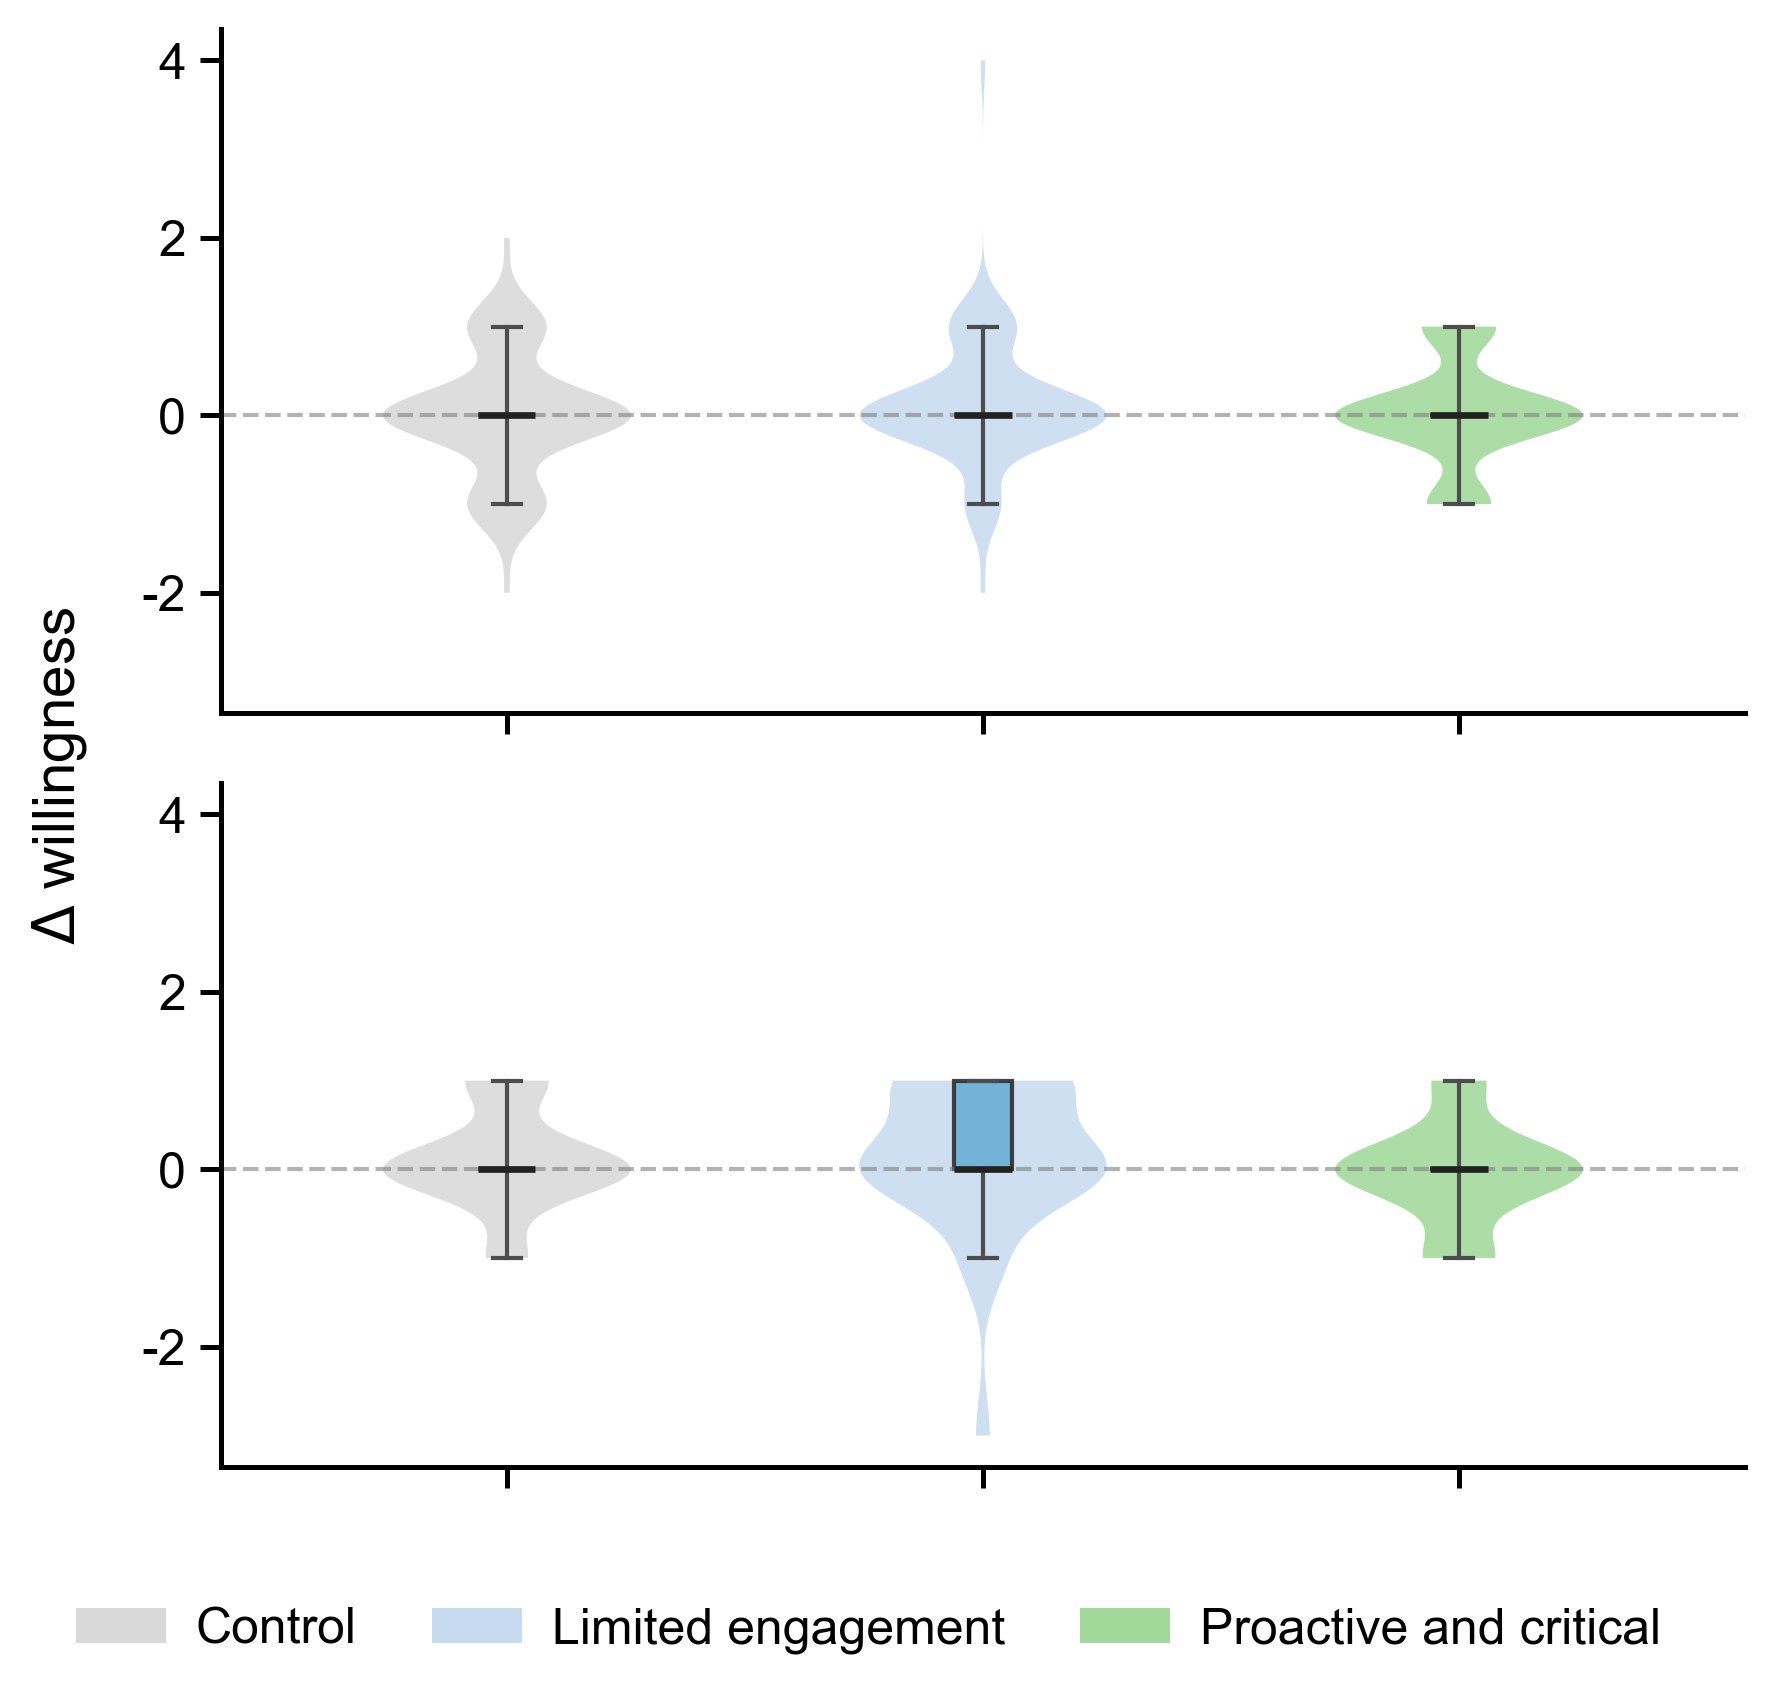

,course,feedback_group,n,mean,ci95_low,ci95_high
0,math,control,79,0.000000,-0.153917,0.153917
1,math,passive,80,0.112500,-0.047256,0.272256
2,math,proactive_critical,78,0.025641,-0.108063,0.159345
3,python,control,27,0.111111,-0.106667,0.328889
4,python,passive,33,0.181818,-0.106869,0.470506
5,python,proactive_critical,21,-0.047619,-0.299792,0.204554


In [5]:
feedback_plots.plot_willingness_delta_by_behavior(
    mechanism_df,
    FIGURES_DIR / "feedback_mechanism_willingness_delta.pdf",
    show_figures=SHOW_FIGURES,
)
survey_feedback.summarize_willingness(mechanism_df)


## Perceived-Risk Shift

This figure summarizes changes in perceived risks (`post - pre`) for overreliance, inaccuracy, and reduced interaction. Panel order: Game Theory top, Python bottom.


Saved plot to: feedback_mechanism_attitude_deltas.pdf


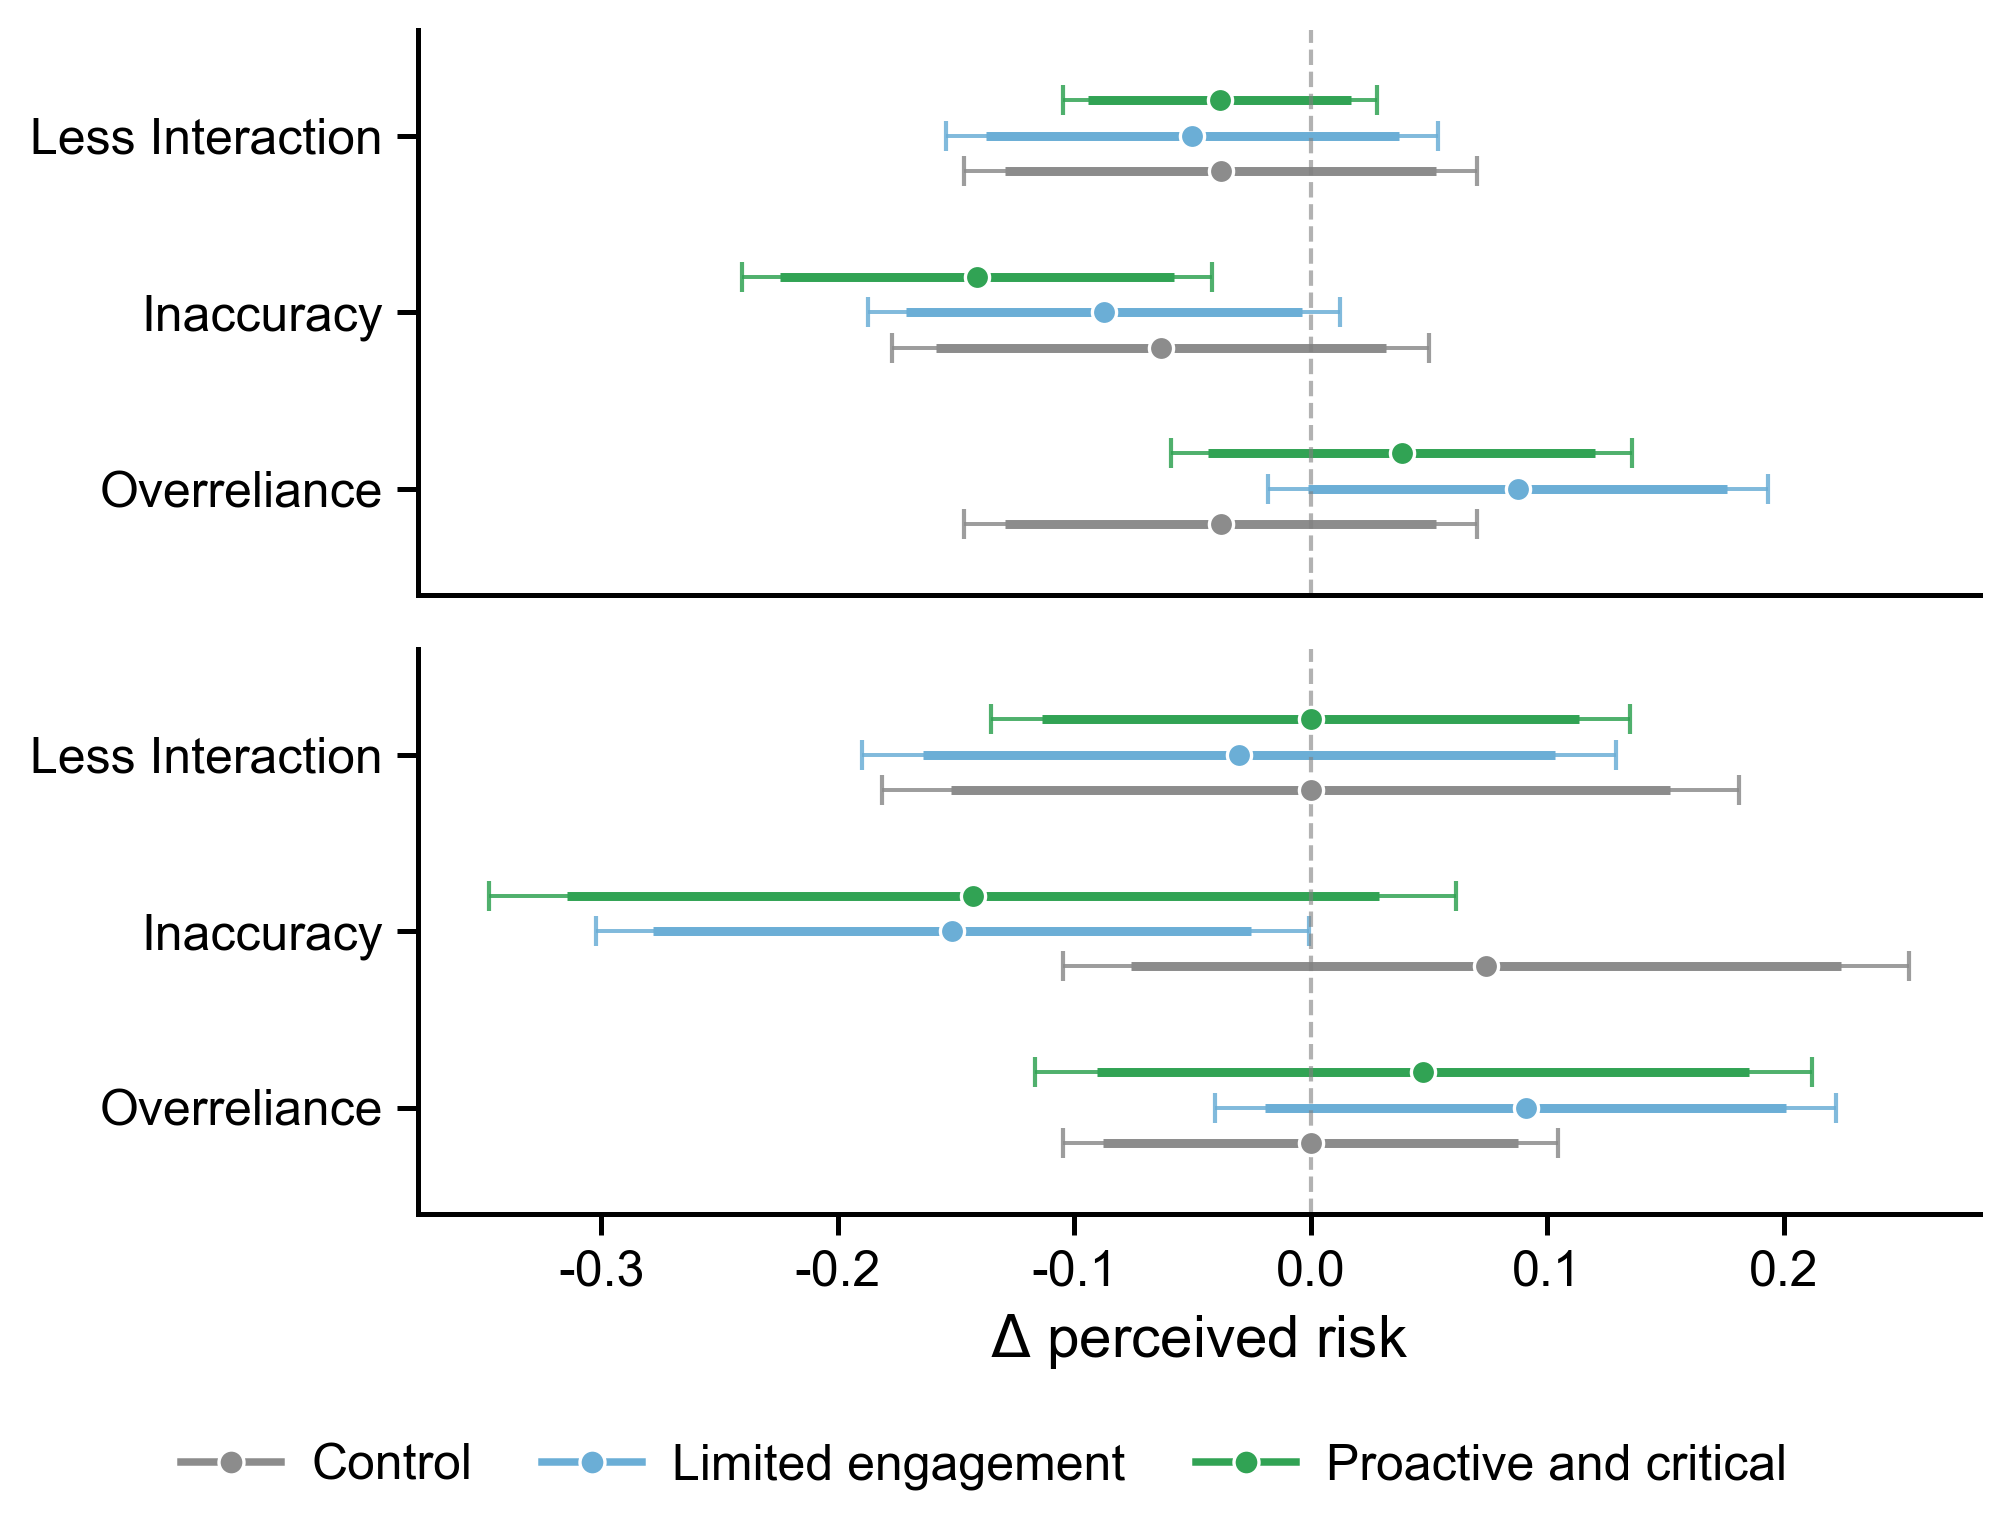

,course,feedback_group,metric,label,n,mean,ci90_low,ci90_high,ci95_low,ci95_high
0,math,control,willingness,Willingness,79,0.000000,-0.129180,0.129180,-0.153917,0.153917
1,math,control,risk_delta_overreliance,Overreliance,79,-0.037975,-0.129045,0.053095,-0.146484,0.070534
2,math,control,risk_delta_inaccuracy,Inaccuracy,79,-0.063291,-0.158597,0.032014,-0.176847,0.050264
3,math,control,risk_delta_less_interaction,Less Interaction,79,-0.037975,-0.129045,0.053095,-0.146484,0.070534
4,math,passive,willingness,Willingness,80,0.112500,-0.021581,0.246581,-0.047256,0.272256
5,math,passive,risk_delta_overreliance,Overreliance,80,0.087500,-0.001230,0.176230,-0.018220,0.193220
6,math,passive,risk_delta_inaccuracy,Inaccuracy,80,-0.087500,-0.171265,-0.003735,-0.187305,0.012305
7,math,passive,risk_delta_less_interaction,Less Interaction,80,-0.050000,-0.137301,0.037301,-0.154018,0.054018
8,math,proactive_critical,willingness,Willingness,78,0.025641,-0.086575,0.137857,-0.108063,0.159345
9,math,proactive_critical,risk_delta_overreliance,Overreliance,78,0.038462,-0.043431,0.120354,-0.059112,0.136035


In [6]:
attitude_deltas = survey_feedback.summarize_attitude_deltas(mechanism_df)
feedback_plots.plot_risk_delta_by_behavior(
    attitude_deltas,
    FIGURES_DIR / "feedback_mechanism_attitude_deltas.pdf",
    show_figures=SHOW_FIGURES,
)
attitude_deltas.head(12)


## Outputs

The generated feedback-mechanism outputs are:

- `feedback_mechanism_self_report_by_behavior.pdf`
- `feedback_mechanism_willingness_delta.pdf`
- `feedback_mechanism_attitude_deltas.pdf`
